In [4]:
#import files and check if the data is downloaded correctly

import pandas as pd



df = pd.read_csv(r"C:\Users\param\OneDrive\Desktop\Coding\customer-churn-prediction\data\raw\telco_churn.csv")
df.info() #view columns, count and type
df.isnull().sum #view the null values
df["Churn"].value_counts() #view how many churns there are

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df.head() #view first 5 rows    

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df = pd.read_csv(r"C:\Users\param\OneDrive\Desktop\Coding\customer-churn-prediction\data\raw\telco_churn.csv")

#drop the customer ID since it is not needed
df = df.drop(columns = ["customerID"])

#convert the charges to numeric 
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

#view where the total charges are NaN
print(df[df["TotalCharges"].isnull()].head())


      gender  SeniorCitizen Partner  ... MonthlyCharges  TotalCharges Churn
488   Female              0     Yes  ...          52.55           NaN    No
753     Male              0      No  ...          20.25           NaN    No
936   Female              0     Yes  ...          80.85           NaN    No
1082    Male              0     Yes  ...          25.75           NaN    No
1340  Female              0     Yes  ...          56.05           NaN    No

[5 rows x 20 columns]


In [7]:
#drop the null total charges and confirm 
df = df.dropna(subset = ["TotalCharges"])

print(df.isnull().sum())
print(df.shape)

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
(7032, 20)


In [8]:
#turn the churn ito numeric values
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


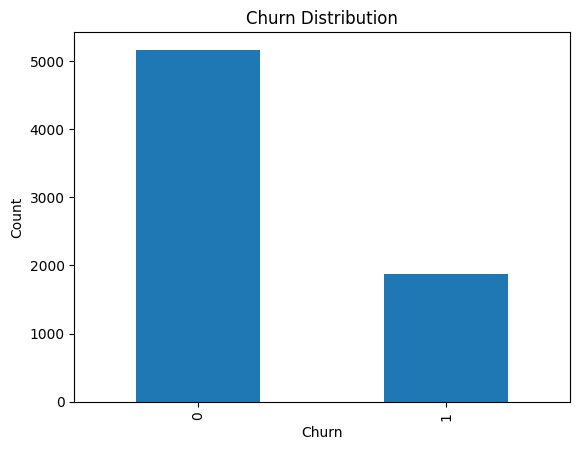

In [10]:
#plot the churn distribution
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

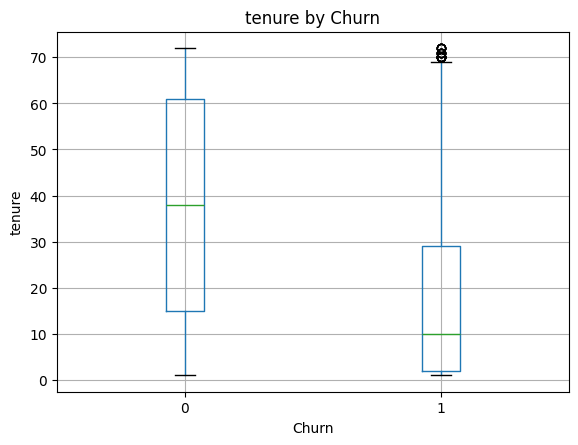

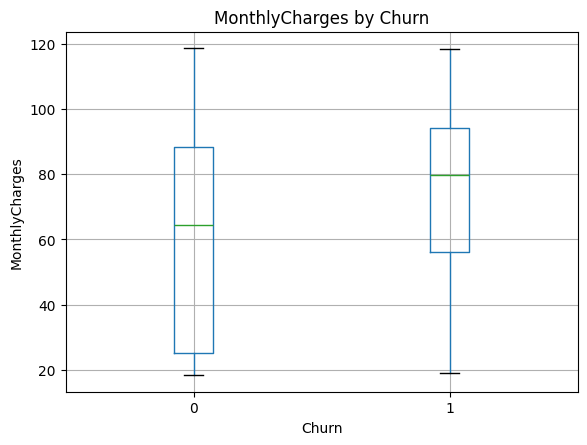

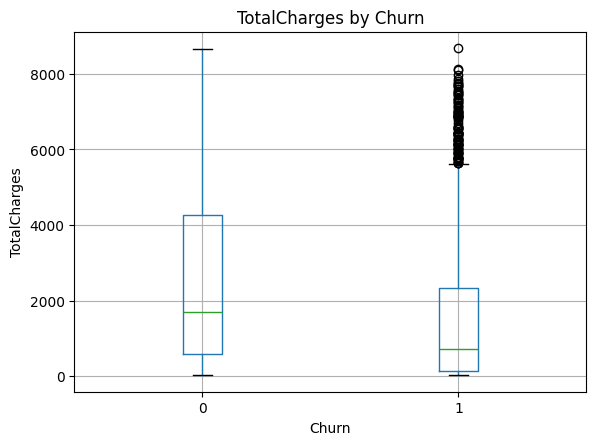

In [11]:
#comapre the key numeric features aganist churn

import matplotlib.pyplot as plt

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    df.boxplot(column=col, by="Churn")
    plt.title(f"{col} by Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

In [12]:
for col in ["Contract", "InternetService", "PaymentMethod"]:
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    print(f"\nChurn rate by {col}:")
    print(churn_rate)


Churn rate by Contract:
Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64

Churn rate by InternetService:
InternetService
Fiber optic    0.418928
DSL            0.189983
No             0.074342
Name: Churn, dtype: float64

Churn rate by PaymentMethod:
PaymentMethod
Electronic check             0.452854
Mailed check                 0.192020
Bank transfer (automatic)    0.167315
Credit card (automatic)      0.152531
Name: Churn, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

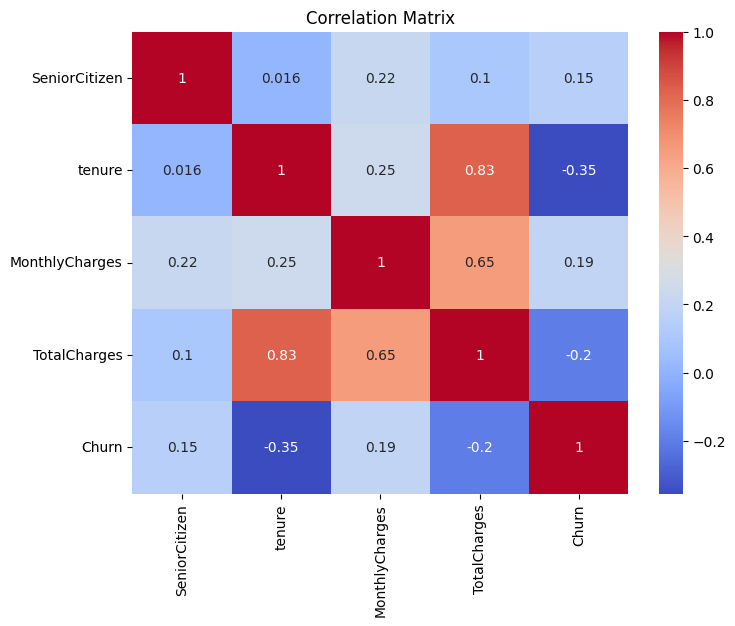

In [13]:
#visualize the relationship w/ correlation heatmaps
corr_matrix = df.corr(numeric_only=True)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show

In [ ]:
#train/test split

from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43, stratify=y)

In [15]:
#seperate the numeric and categorical columns

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
#preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])



In [17]:
#baseline model, logistic regression

from sklearn.linear_model import LogisticRegression

logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
#predictions

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = logreg_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.806680881307747

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



ROC AUC: 0.8526875152067339


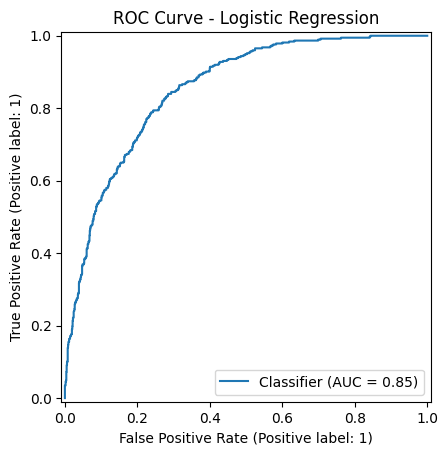

In [19]:
#roc auc

from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_proba = logreg_model.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Logistic Regression")
plt.show()


In [20]:
#stronger model, random forest

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("Random Forest ROC AUC:", roc_auc_score(y_test, y_proba_rf))


              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

Random Forest ROC AUC: 0.8387827365391286


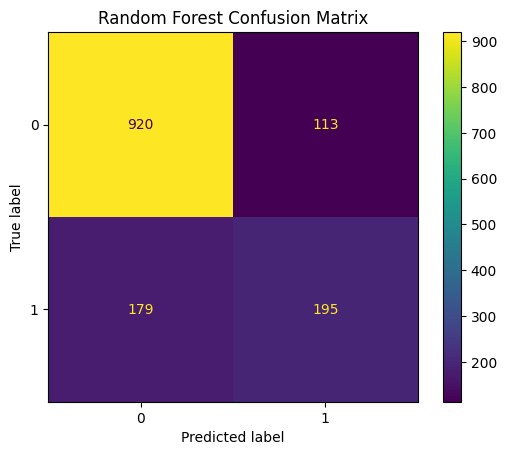

In [21]:
#confusion matrix

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


In [22]:
#compare with logistic regression

y_pred_lr = logreg_model.predict(X_test)
y_proba_lr = logreg_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))
print("Logistic Regression ROC AUC:", roc_auc_score(y_test, y_proba_lr))

print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest ROC AUC:", roc_auc_score(y_test, y_proba_rf))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407

Logistic Regression ROC AUC: 0.8526875152067339

Random Forest Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

Random Forest ROC AUC: 0.8387827365391286


In [26]:
#stronger random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

rf_stronger = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=750,
        max_depth=10,
        min_samples_split=12,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_stronger.fit(X_train, y_train)

y_pred_rf_stronger = rf_stronger.predict(X_test)
y_proba_rf_stronger = rf_stronger.predict_proba(X_test)[:, 1]

print("Stronger Random Forest Report:")
print(classification_report(y_test, y_pred_rf_stronger))
print("Stronger Random Forest ROC AUC:", roc_auc_score(y_test, y_proba_rf_stronger))


Stronger Random Forest Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1033
           1       0.54      0.79      0.64       374

    accuracy                           0.77      1407
   macro avg       0.73      0.78      0.74      1407
weighted avg       0.81      0.77      0.78      1407

Stronger Random Forest ROC AUC: 0.8587262063146125


In [43]:
#lower the threshold

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_proba_rf = rf_stronger.predict_proba(X_test)[:, 1]

threshold = 0.35
y_pred_rf_thresh = (y_proba_rf >= threshold).astype(int)

print(f"Threshold: {threshold}")
print(classification_report(y_test, y_pred_rf_thresh))



Threshold: 0.35
              precision    recall  f1-score   support

           0       0.95      0.64      0.76      1033
           1       0.47      0.90      0.62       374

    accuracy                           0.71      1407
   macro avg       0.71      0.77      0.69      1407
weighted avg       0.82      0.71      0.72      1407



SHAP shape used: (1407, 45)
Data shape: (1407, 45)


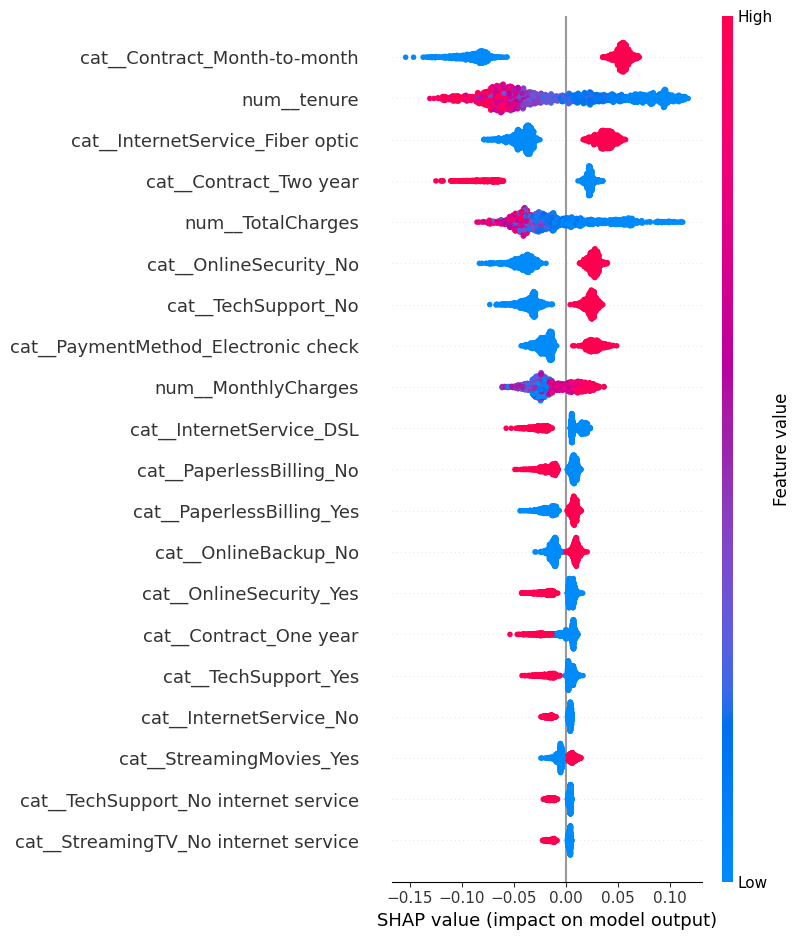

In [45]:
import shap
import numpy as np

X_test_transformed = rf_stronger.named_steps["preprocessor"].transform(X_test)
feature_names = rf_stronger.named_steps["preprocessor"].get_feature_names_out()
rf_classifier = rf_stronger.named_steps["classifier"]

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_test_transformed)

if isinstance(shap_values, list):
    shap_for_class1 = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_for_class1 = shap_values[:, :, 1]
else:
    shap_for_class1 = shap_values

print("SHAP shape used:", shap_for_class1.shape)
print("Data shape:", X_test_transformed.shape)

shap.summary_plot(shap_for_class1, X_test_transformed, feature_names=feature_names)



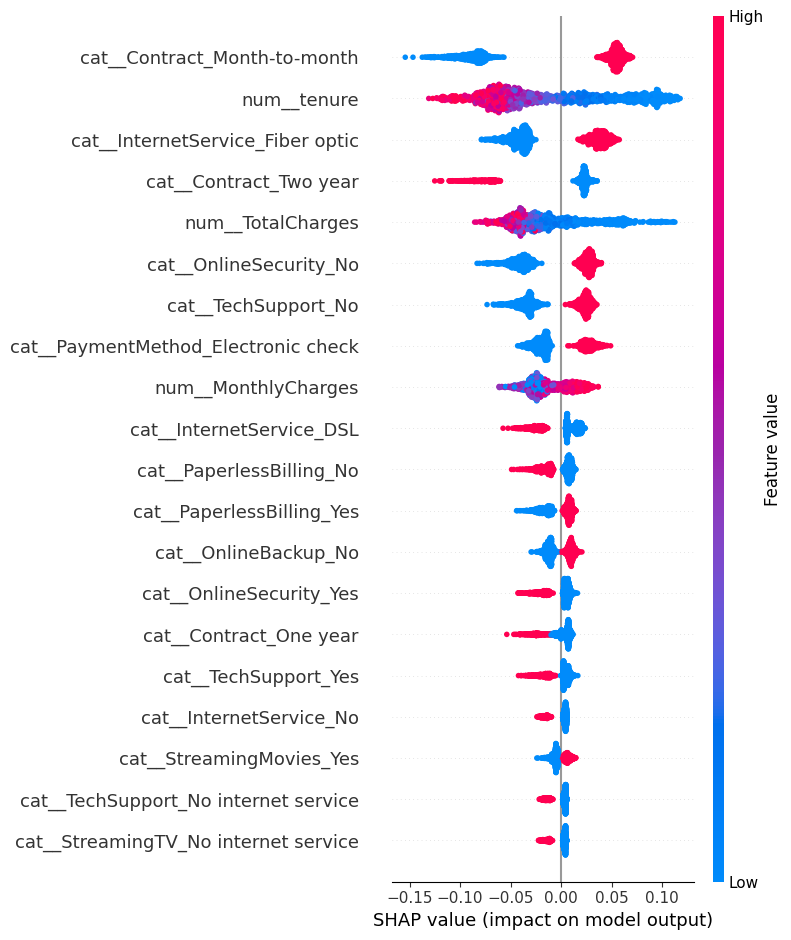

In [ ]:
#save figure 

import matplotlib.pyplot as plt
import os

os.makedirs("outputs/figures", exist_ok=True)

shap.summary_plot(
    shap_for_class1,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig("outputs/figures/shap_summary_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()


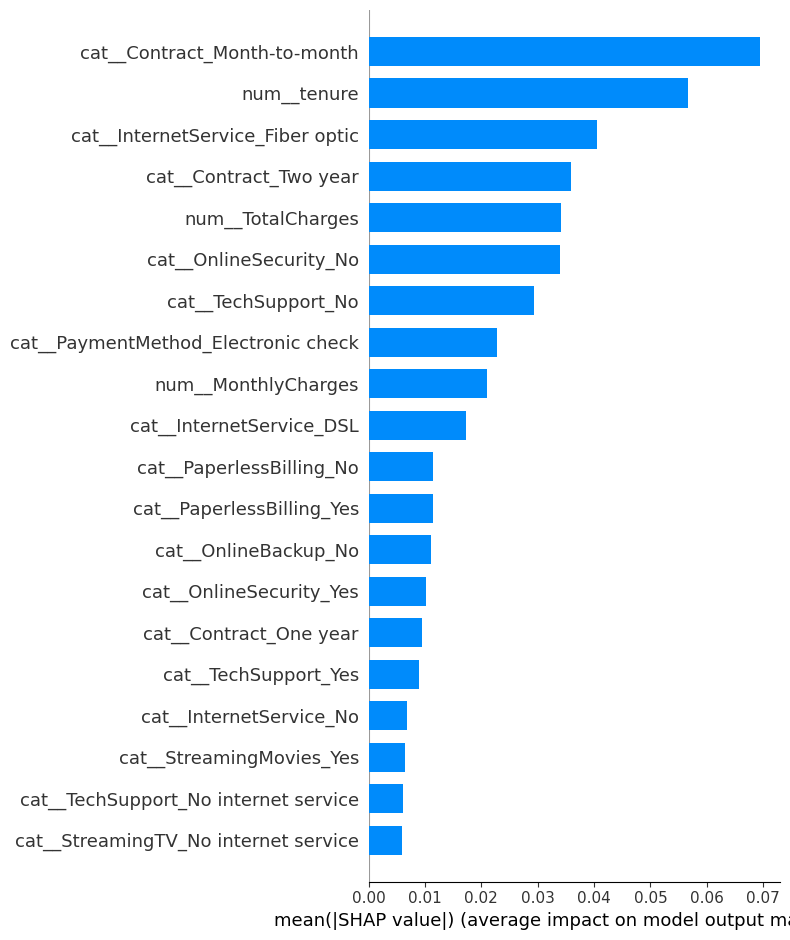

In [47]:
#bar plot instead of a beeswarm
shap.summary_plot(
    shap_for_class1,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("outputs/figures/shap_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()


In [48]:
#save the model

import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(rf_stronger, "models/churn_model.pkl")


['models/churn_model.pkl']

In [49]:
#test the model to ensure its working

loaded_model = joblib.load("models/churn_model.pkl")
print(loaded_model.predict(X_test.head()))
print(loaded_model.predict_proba(X_test.head())[:, 1])


[0 1 0 0 0]
[0.37777073 0.60170309 0.05210101 0.15576634 0.16927077]
